# 12 - Structure-distance end-to-end showcase (SMD + OPW order-gap)

**Author** - kj &nbsp;|&nbsp; **Approach** - the OPW order-gap (E10-H55), the single structure number that ships beside SMD

Two documents in, two closeness numbers out: semantic (SMD - how far in meaning) and structural (the OPW order-gap - how far in arrangement). The structure number is **content-invariant by construction** - subtracting SMD from the order-preserving transport cost cancels the content term, so a reword reads ~0 and a reorder reads large.

- **Semantic** - SMD closeness `1 − SMD/√2`, the order-invariant content axis
- **Structural** - `structure_closeness = 1 − gap/√2`, `gap = OPW − SMD`, the order-sensitive arrangement axis
- **The proof point** - a reorder drops structural closeness but not semantic; a paraphrase drops semantic but not structural - the two axes are orthogonal
- **Decided by E11** - the order-gap replaced the position-augmented metric, which fused content and arrangement and read a reword as large as a reorder

## GPU selection

mmBERT statement embedding runs on the RTX 5000 Ada (GPU 2), pinned by UUID. The OT math is CPU numpy.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-c15a4c9a-8c2c-7fb9-a46b-fe4dff5dacf4"  # RTX 5000 Ada
os.environ["TOKENIZERS_PARALLELISM"] = "false"; os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda", torch.cuda.is_available(), "|",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.12.1+cu130 | cuda True | NVIDIA RTX 5000 Ada Generation


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import ot
from docdistance.distance import cost_matrix, smd, transport_plan, closeness, SMD_MAX
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready | POT", ot.__version__)

imports ready | POT 0.9.6.post1


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

The shipped mechanism and its parameters. `gap = OPW − SMD` is read as `structure_closeness = 1 − gap/√2`, the same
`1 − d/√2` scale as semantic closeness. OPW parameters are the Su & Hua / E10 defaults.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
FIX = ROOT / "data/processed/structure-fixture"

OPW_L1, OPW_L2, OPW_SIG = 50.0, 0.1, 1.0   # Su & Hua / E10-H55 OPW defaults
LAM_FUSED = 0.25                            # E08-H44 position-augmented weight (the dropped metric, for contrast only)
REORDER_SWAPS = 14                          # seeded transpositions for the reordered-but-faithful pair
MOVER_THRESH = 0.10                         # |delta| (normalized position) flagging a statement as a mover

DOCS = json.loads((FIX / "statements.json").read_text())
ENC = load_encoder("torch", offline=True, device="cuda")
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

t = Table(title="Notebook 12 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("Structure metric", "OPW order-gap (E10-H55), the shipped single number")
t.add_row("OPW params", f"lambda1={OPW_L1}, lambda2={OPW_L2}, sigma={OPW_SIG}")
t.add_row("Readout", "structure_closeness = 1 - gap/sqrt(2),  sqrt(2) = " + f"{SMD_MAX:.4f}")
t.add_row("Reorder", f"{REORDER_SWAPS} seeded swaps (the byte-identical scramble)")
t.add_row("Fused metric (dropped)", f"position-augmented Wasserstein, lambda={LAM_FUSED} (contrast only)")
console.print(t)

                                Notebook 12 configuration                                
  Device                    NVIDIA RTX 5000 Ada Generation                               
  Structure metric          OPW order-gap (E10-H55), the shipped single number           
  OPW params                lambda1=50.0, lambda2=0.1, sigma=1.0                         
  Readout                   structure_closeness = 1 - gap/sqrt(2),  sqrt(2) = 1.4142     
  Reorder                   14 seeded swaps (the byte-identical scramble)                
  Fused metric (dropped)    position-augmented Wasserstein, lambda=0.25 (contrast only)

## Mechanisms

SMD is the order-free transport cost (exact EMD); OPW is the order-preserving cost (log-stabilized Sinkhorn under an
inverse-difference-moment reward and a Gaussian temporal prior). The gap `OPW − SMD` cancels the content term. The
position-augmented metric is defined only to show why it was dropped.

In [5]:
def pos_vec(n):
    return np.arange(n) / max(n - 1, 1)

# --- OPW order-gap (E10-H55), the shipped structure metric ---
def opw_plan(EA, EB, l1=OPW_L1, l2=OPW_L2, sig=OPW_SIG, iters=100):
    N, M = len(EA), len(EB); D = cost_matrix(EA, EB)
    i = (np.arange(1, N + 1) / N)[:, None]; j = (np.arange(1, M + 1) / M)[None, :]
    mid = np.abs(i - j) / np.sqrt(1 / N ** 2 + 1 / M ** 2)
    logP = -mid ** 2 / (2 * sig ** 2) - np.log(sig * np.sqrt(2 * np.pi))
    S = l1 / ((i - j) ** 2 + 1)
    logK = logP + (S - D) / l2; logK = logK - logK.max(); K = np.exp(logK)
    a, b = np.full(N, 1 / N), np.full(M, 1 / M); u = np.ones(N) / N
    for _ in range(iters):
        v = b / (K.T @ u + 1e-300); u = a / (K @ v + 1e-300)
    return u[:, None] * K * v[None, :]

def opw_gap(EA, EB):
    return float((opw_plan(EA, EB) * cost_matrix(EA, EB)).sum()) - smd(EA, EB)

def structure_closeness(EA, EB):
    return 1.0 - max(opw_gap(EA, EB), 0.0) / SMD_MAX     # 1 - gap/sqrt(2), bounded [0,1]

# --- position-augmented Wasserstein (E08-H44, the dropped metric) - contrast only ---
def posaug_smd(EA, EB, lam, posA=None, posB=None):
    d = cost_matrix(EA, EB)
    pa = pos_vec(len(EA)) if posA is None else posA
    pb = pos_vec(len(EB)) if posB is None else posB
    dp = np.abs(pa[:, None] - pb[None, :])
    M = np.sqrt((1 - lam) * d ** 2 + lam * dp ** 2)
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return float(ot.emd2(a, b, M))

def induced_mapping(T, posB):
    tau = (T @ posB) / (T.sum(1) + 1e-12)
    return tau, T.argmax(1)

def trunc(s, n=46):
    s = s.replace("\n", " ").strip()
    return s if len(s) <= n else s[: n - 1] + "."

print("mechanisms defined: SMD (content), OPW order-gap (structure), posaug (dropped, contrast)")

mechanisms defined: SMD (content), OPW order-gap (structure), posaug (dropped, contrast)


## Documents and pairs

The fixture supplies the gold IBM summary, its opus-mt back-translation paraphrase (`gold~bt` - reworded, order
preserved), and a different-content summary (`sonnet`). Four contrasting pairs make the two axes legible.

In [6]:
ST_A = DOCS["gold"]["statements"]
ST_BT = DOCS["gold~bt"]["statements"]          # back-translation reword, same order
ST_S = DOCS["sonnet"]["statements"]
nA = len(ST_A)

EMB_A = ENC.encode(ST_A)
EMB_BT = ENC.encode(ST_BT)
EMB_S = ENC.encode(ST_S)

# seeded reorder of gold (faithful content, rearranged order)
rng = np.random.default_rng(SEED); perm = np.arange(nA)
for _ in range(REORDER_SWAPS):
    a, b = int(rng.integers(0, nA)), int(rng.integers(0, nA)); perm[a], perm[b] = perm[b], perm[a]
EMB_A_RE = EMB_A[perm]
reorder_disp = float(np.abs(perm - np.arange(nA)).sum()) / (nA * nA // 2)

PAIRS = [
    {"name": "identity", "EA": EMB_A, "EB": EMB_A, "col": "#2ca02c"},
    {"name": "reordered-but-faithful", "EA": EMB_A, "EB": EMB_A_RE, "col": "#d62728"},
    {"name": "paraphrased-but-faithful", "EA": EMB_A, "EB": EMB_BT, "col": "#9467bd"},
    {"name": "different-content", "EA": EMB_A, "EB": EMB_S, "col": "#1f77b4"},
]
t = Table(title="Documents and pairs", title_style="bold cyan")
for c in ("pair", "doc A -> doc B", "n_A x n_B"):
    t.add_column(c, style="cyan" if c == "pair" else None)
t.add_row("identity", "gold -> gold", f"{nA}x{nA}")
t.add_row("reordered-but-faithful", f"gold -> gold ({REORDER_SWAPS} swaps, disp {reorder_disp:.2f})", f"{nA}x{nA}")
t.add_row("paraphrased-but-faithful", "gold -> gold~bt (back-translation reword)", f"{nA}x{len(ST_BT)}")
t.add_row("different-content", "gold -> sonnet", f"{nA}x{len(ST_S)}")
console.print(t)

                                Documents and pairs                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ pair                     ┃ doc A -> doc B                            ┃ n_A x n_B ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ identity                 │ gold -> gold                              │ 14x14     │
│ reordered-but-faithful   │ gold -> gold (14 swaps, disp 0.69)        │ 14x14     │
│ paraphrased-but-faithful │ gold -> gold~bt (back-translation reword) │ 14x14     │
│ different-content        │ gold -> sonnet                            │ 14x13     │
└──────────────────────────┴───────────────────────────────────────────┴───────────┘

## Two-axis readout - semantic vs structural

Both numbers come off the same embeddings: SMD closeness (content) and structure closeness `1 − gap/√2` (arrangement).
The proof is the orthogonality - the reordered pair drops on structure, the paraphrased pair drops on semantic.

In [7]:
rows = []
for p in PAIRS:
    d_sem = smd(p["EA"], p["EB"])
    gap = max(opw_gap(p["EA"], p["EB"]), 0.0)
    rows.append({"pair": p["name"], "SMD": d_sem, "sem_close": closeness(d_sem),
                 "gap": gap, "struct_close": 1.0 - gap / SMD_MAX, "col": p["col"]})
readout = pd.DataFrame(rows)

t = Table(title="Two-axis readout - semantic (SMD) vs structural (OPW order-gap)", title_style="bold cyan")
for c in ("pair", "SMD", "sem closeness", "gap", "struct closeness", "reads as"):
    t.add_column(c, justify="left" if c in ("pair", "reads as") else "right")
verdict = {"identity": "same / same", "reordered-but-faithful": "same meaning, changed arrangement",
           "paraphrased-but-faithful": "reworded meaning, same arrangement",
           "different-content": "different meaning, similar arrangement"}
for r in rows:
    style = "bold yellow" if r["pair"] in ("reordered-but-faithful", "paraphrased-but-faithful") else None
    t.add_row(r["pair"], f'{r["SMD"]:.3f}', f'{r["sem_close"]:.3f}', f'{r["gap"]:.4f}',
              f'{r["struct_close"]:.3f}', verdict[r["pair"]], style=style)
console.print(t)

                          Two-axis readout - semantic (SMD) vs structural (OPW order-gap)                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ pair                     ┃   SMD ┃ sem closeness ┃    gap ┃ struct closeness ┃ reads as                         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ identity                 │ 0.000 │         1.000 │ 0.0005 │            1.000 │ same / same                      │
│ reordered-but-faithful   │ 0.000 │         1.000 │ 0.4783 │            0.662 │ same meaning, changed            │
│                          │       │               │        │                  │ arrangement                      │
│ paraphrased-but-faithful │ 0.208 │         0.853 │ 0.0019 │            0.999 │ reworded meaning, same           │
│                          │       │               │        │                  │ arrangement                      │
│ different-content        │ 0.370 │         0.738 │ 0.0654 │            0.954 │ different meaning, similar       │
│                          │       │               │        │                  │ arrangement                      │
└──────────────────────────┴───────┴───────────────┴────────┴──────────────────┴──────────────────────────────────┘

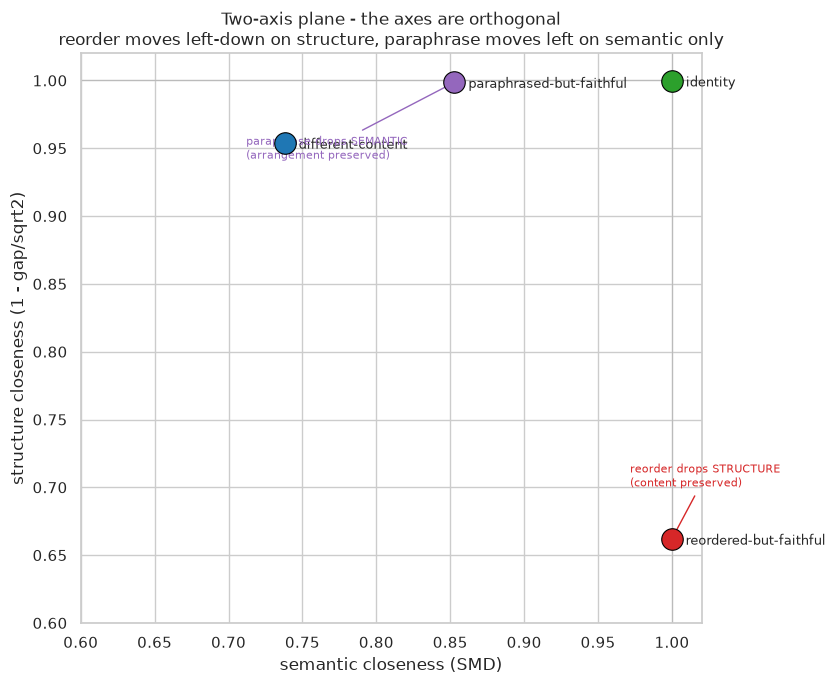

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.axhline(1.0, color="#bbbbbb", lw=0.8); ax.axvline(1.0, color="#bbbbbb", lw=0.8)
for r in rows:
    ax.scatter(r["sem_close"], r["struct_close"], s=240, color=r["col"], edgecolor="black", linewidth=0.8, zorder=5)
    ax.annotate(r["pair"], (r["sem_close"], r["struct_close"]), textcoords="offset points",
                xytext=(10, -4), fontsize=9)
ax.annotate("reorder drops STRUCTURE\n(content preserved)", (rows[1]["sem_close"], rows[1]["struct_close"]),
            textcoords="offset points", xytext=(-30, 38), fontsize=8, color="#d62728",
            arrowprops=dict(arrowstyle="->", color="#d62728"))
ax.annotate("paraphrase drops SEMANTIC\n(arrangement preserved)", (rows[2]["sem_close"], rows[2]["struct_close"]),
            textcoords="offset points", xytext=(-150, -55), fontsize=8, color="#9467bd",
            arrowprops=dict(arrowstyle="->", color="#9467bd"))
ax.set(xlim=(0.6, 1.02), ylim=(0.6, 1.02), xlabel="semantic closeness (SMD)", ylabel="structure closeness (1 - gap/sqrt2)",
       title="Two-axis plane - the axes are orthogonal\nreorder moves left-down on structure, paraphrase moves left on semantic only")
plt.tight_layout(); plt.show()

## Why the order-gap, not the fused metric

The dropped metric (position-augmented Wasserstein) fuses content and position, so a reword and a uniform shift both
fire it even though neither rearranges content. The order-gap subtracts SMD and reads both at ~0. This is the E11
content-invariance result, on one pair.

In [9]:
# pure shift of gold (positions translated, content + order fixed) - only the fused metric can see it
S = 4; Lmax = (nA - 1) + S
pa, pb = np.arange(nA) / Lmax, (np.arange(nA) + S) / Lmax

contrast = [
    ("paraphrase (gold~bt)", posaug_smd(EMB_A, EMB_BT, LAM_FUSED), max(opw_gap(EMB_A, EMB_BT), 0.0)),
    ("pure shift (+4)",       posaug_smd(EMB_A, EMB_A, LAM_FUSED, pa, pb), max(opw_gap(EMB_A, EMB_A), 0.0)),
    ("reorder (real signal)", posaug_smd(EMB_A, EMB_A_RE, LAM_FUSED), max(opw_gap(EMB_A, EMB_A_RE), 0.0)),
]
t = Table(title="Content-invariance contrast - neither a reword nor a shift is a rearrangement", title_style="bold cyan")
for c in ("case", "fused metric H44 (dropped)", "order-gap H55 (shipped)"):
    t.add_column(c, justify="left" if c == "case" else "right")
for name, h44, h55 in contrast:
    style = "bold red" if "reorder" not in name else "bold green"
    t.add_row(name, f"{h44:.3f}", f"{h55:.4f}", style=style)
console.print(t)
print("the fused metric fires on a reword and a shift (false structure); the order-gap reads them ~0 and only the reorder large")

 Content-invariance contrast - neither a reword nor a shift is a rearrangement  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ case                  ┃ fused metric H44 (dropped) ┃ order-gap H55 (shipped) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ paraphrase (gold~bt)  │                      0.180 │                  0.0019 │
│ pure shift (+4)       │                      0.118 │                  0.0005 │
│ reorder (real signal) │                      0.187 │                  0.4783 │
└───────────────────────┴────────────────────────────┴─────────────────────────┘

the fused metric fires on a reword and a shift (false structure); the order-gap reads them ~0 and only the reorder large


## Transport plans - content plan vs order-preserving plan

The structure signal is the gap between two couplings of the same statements: the SMD content plan (order-free, exact)
and the OPW order-preserving plan (held near the diagonal by the temporal prior). On a reorder the content plan goes
off-diagonal to follow the moved statements; the OPW plan pays extra to stay in order, and that extra cost is the gap.

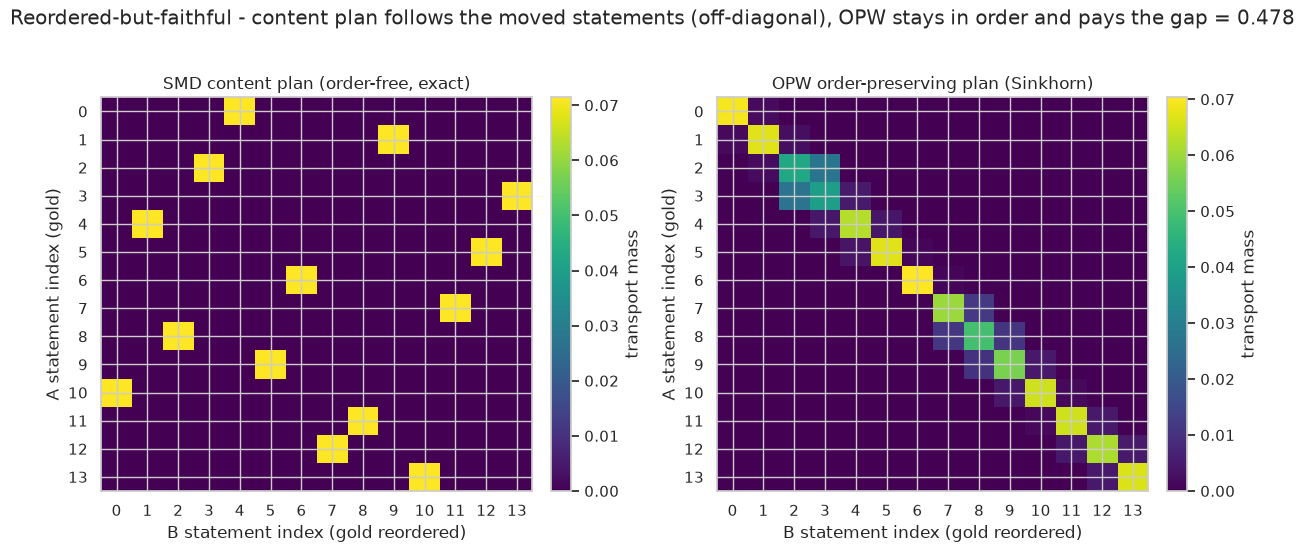

In [10]:
head = PAIRS[1]   # reordered-but-faithful
T_smd = transport_plan(head["EA"], head["EB"])     # content-optimal (exact EMD)
T_opw = opw_plan(head["EA"], head["EB"])           # order-preserving (Sinkhorn)
gap_head = max(opw_gap(head["EA"], head["EB"]), 0.0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax, T, title in ((axes[0], T_smd, "SMD content plan (order-free, exact)"),
                     (axes[1], T_opw, "OPW order-preserving plan (Sinkhorn)")):
    im = ax.imshow(T, cmap="viridis", aspect="auto")
    ax.set(xlabel="B statement index (gold reordered)", ylabel="A statement index (gold)", title=title)
    ax.set_xticks(range(len(head["EB"]))); ax.set_yticks(range(len(head["EA"])))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="transport mass")
fig.suptitle(f"Reordered-but-faithful - content plan follows the moved statements (off-diagonal), "
             f"OPW stays in order and pays the gap = {gap_head:.3f}", y=1.02)
plt.tight_layout(); plt.show()

## Movers - per-statement displacement off the content plan

The content plan is the statement-to-statement alignment; each statement's induced target position `τ(i)` and
displacement `δ(i) = τ(i) − pos(i)` name what moved. On the reordered pair the movers are the statements the gap
charges for.

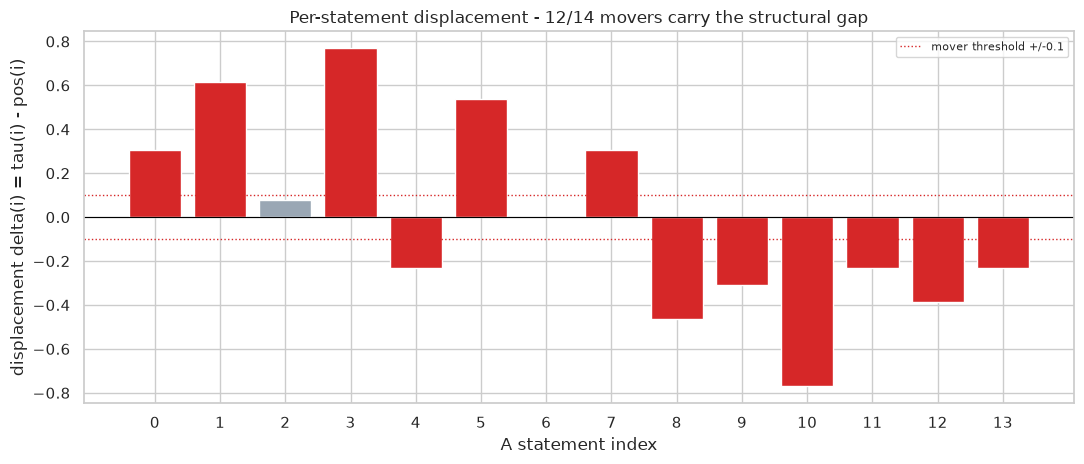

largest movers:
  statement 10 at pos 0.77 -> tau 0.00 (delta -0.77): Intent on trustworthy AI outruns action.
  statement 3 at pos 0.23 -> tau 1.00 (delta +0.77): Among organizations with more than 1,000 empl.
  statement 1 at pos 0.08 -> tau 0.69 (delta +0.62): Enterprise AI adoption splits into a widening.


In [11]:
posB = pos_vec(len(head["EB"]))
tau, matched = induced_mapping(T_smd, posB)
pos = pos_vec(len(head["EA"])); delta = tau - pos
n_movers = int((np.abs(delta) > MOVER_THRESH).sum())

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(np.arange(nA), delta, color=["#d62728" if abs(d) > MOVER_THRESH else "#9aa7b4" for d in delta])
ax.axhline(0, color="black", lw=0.8)
ax.axhline(MOVER_THRESH, color="#d62728", ls=":", lw=1, label=f"mover threshold +/-{MOVER_THRESH}")
ax.axhline(-MOVER_THRESH, color="#d62728", ls=":", lw=1)
ax.set(xlabel="A statement index", ylabel="displacement delta(i) = tau(i) - pos(i)",
       title=f"Per-statement displacement - {n_movers}/{nA} movers carry the structural gap")
ax.set_xticks(np.arange(nA)); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

top = np.argsort(-np.abs(delta))[:3]
print("largest movers:")
for i in top:
    print(f"  statement {i} at pos {pos[i]:.2f} -> tau {tau[i]:.2f} (delta {delta[i]:+.2f}): {trunc(ST_A[i])}")

## Conclusion

The order-gap ships one structure number beside SMD, and the two axes separate content drift from rearrangement.

- **Orthogonal axes** - the reordered pair drops structure closeness (arrangement changed) at high semantic closeness; the paraphrased pair drops semantic closeness (reworded) at structure closeness ~1
- **Content-invariant** - a reword and a uniform shift both read ~0 on the order-gap; only a genuine reorder reads large, the property the fused metric lacked
- **One bounded number** - `structure_closeness = 1 − gap/√2 ∈ [0,1]`, the same scale as semantic closeness, no second model
- **Interpretable** - the content plan names the movers; each statement's induced displacement is an `O(n)` read off the already-computed coupling